Health Risk Stratification for Pregnancy

Maternal Health Risk Assessment Dataset
https://data.mendeley.com/datasets/p5w98dvbbk/1

In [2]:
#data preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import joblib
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import shap

filepath = "dataset/health_risk_pregnancy.csv"

In [3]:
df = pd.read_csv(filepath)
print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   str    
dtypes: float64(7), int64(4), str(1)
memory usage: 113.1 KB
None


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [4]:
df['Risk Level'] = df['Risk Level'].map({'Low': 0, 'High': 1})

df = df.dropna()


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 1166 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1166 non-null   int64  
 1   Systolic BP             1166 non-null   float64
 2   Diastolic               1166 non-null   float64
 3   BS                      1166 non-null   float64
 4   Body Temp               1166 non-null   int64  
 5   BMI                     1166 non-null   float64
 6   Previous Complications  1166 non-null   float64
 7   Preexisting Diabetes    1166 non-null   float64
 8   Gestational Diabetes    1166 non-null   int64  
 9   Mental Health           1166 non-null   int64  
 10  Heart Rate              1166 non-null   float64
 11  Risk Level              1166 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 118.4 KB


In [6]:
columns = [features for features in df.columns]
X = df[[features for features in columns if features != "Risk Level"]]
y = df["Risk Level"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
len(columns)

12

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

## Model Prediction

In [9]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

joblib.dump(clf,"saved_models/clf.joblib")
 
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       141
         1.0       0.96      0.98      0.97        93

    accuracy                           0.97       234
   macro avg       0.97      0.98      0.97       234
weighted avg       0.97      0.97      0.97       234

AUC: 0.9943567452146724


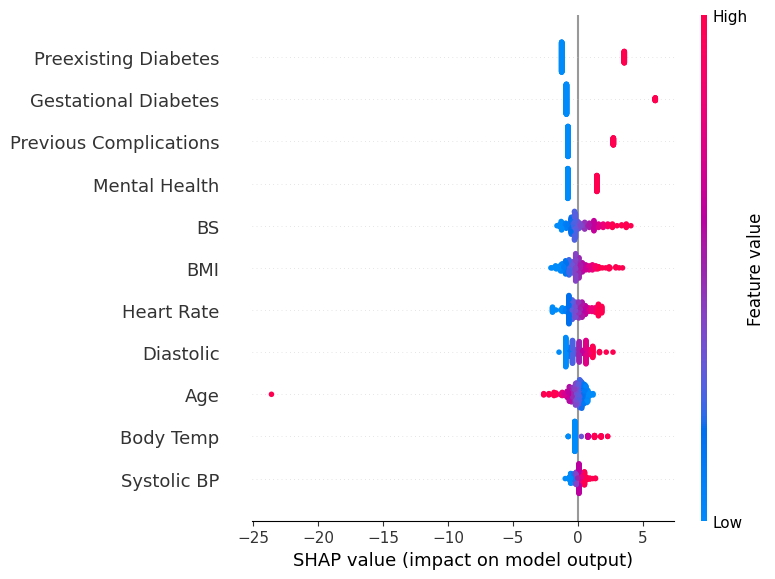

In [10]:
explainer = shap.Explainer(clf, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=columns)


In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
joblib.dump(rf,'saved_models/rf.joblib')

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print('Random Forest AUC:', roc_auc_score(y_test, y_prob_rf))


              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       141
         1.0       0.99      0.99      0.99        93

    accuracy                           0.99       234
   macro avg       0.99      0.99      0.99       234
weighted avg       0.99      0.99      0.99       234

Random Forest AUC: 0.9996186990009914


In [13]:
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

joblib.dump(xgb_model,"saved_models/xgb_model.joblib")

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print('XGBoost AUC:', roc_auc_score(y_test, y_prob_xgb))


              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       141
         1.0       0.99      0.99      0.99        93

    accuracy                           0.99       234
   macro avg       0.99      0.99      0.99       234
weighted avg       0.99      0.99      0.99       234

XGBoost AUC: 0.9993136582017844


In [14]:
mlp = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

joblib.dump(mlp,"saved_models/mlp.joblib")

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_mlp))
print('MLP AUC:', roc_auc_score(y_test, y_prob_mlp))


              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       141
         1.0       0.96      0.98      0.97        93

    accuracy                           0.97       234
   macro avg       0.97      0.98      0.97       234
weighted avg       0.97      0.97      0.97       234

MLP AUC: 0.9981697552047587


In [15]:
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train, y_train)
joblib.dump(svc,"saved_models/svc.joblib")
y_pred_svc = svc.predict(X_test)
y_prob_svc = svc.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svc))
print('SVM AUC:', roc_auc_score(y_test, y_prob_svc))


              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98       141
         1.0       0.95      0.99      0.97        93

    accuracy                           0.97       234
   macro avg       0.97      0.98      0.97       234
weighted avg       0.98      0.97      0.97       234

SVM AUC: 0.9967970716083276


# Inference and Evaluation

In [36]:
import os
model_folder = 'saved_models/'

models = {}
results = {}
for filename in os.listdir(model_folder):
    if filename.endswith('.joblib'):
        # Create the full path to the file
        file_path = os.path.join(model_folder, filename)
        
        # Strip the .joblib extension to use as a clean column name
        model_name = filename.replace('.joblib', '')
        
        # Load the model and add it to the dictionary
        models[model_name] = joblib.load(file_path)

for name, model in models.items():
    # Ensure the model supports probability predictions
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, probs)
        results[f"{name}"] = float(roc)
    else:
        print(f"Skipping {name}: Does not support predict_proba.")
    
    

res = pd.DataFrame.from_dict(results, orient='index',columns = ["ROC AUC"])
res

,ROC AUC
clf,0.994357
mlp,0.998170
rf,0.999619
svc,0.996797
xgb_model,0.999314


# Visualization

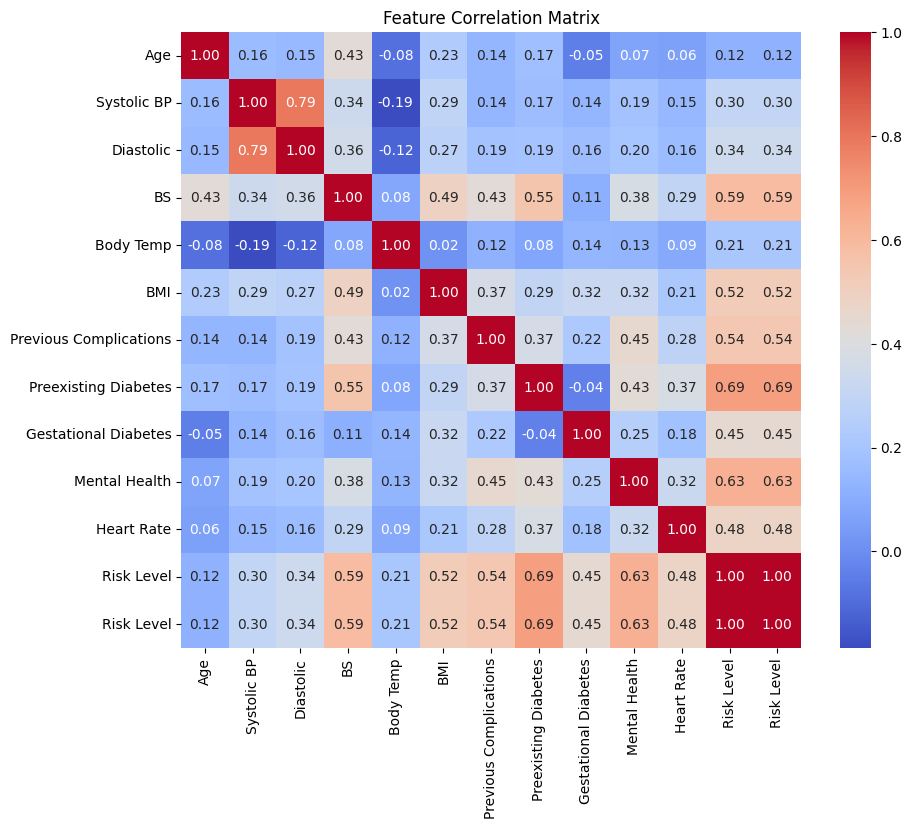

In [18]:
corr = df[columns + ['Risk Level']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

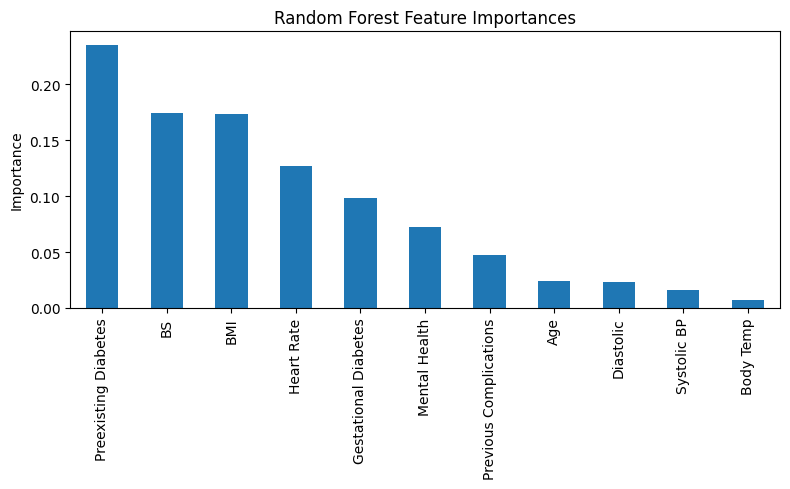

In [19]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=[features for features in columns if features != "Risk Level"]).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()


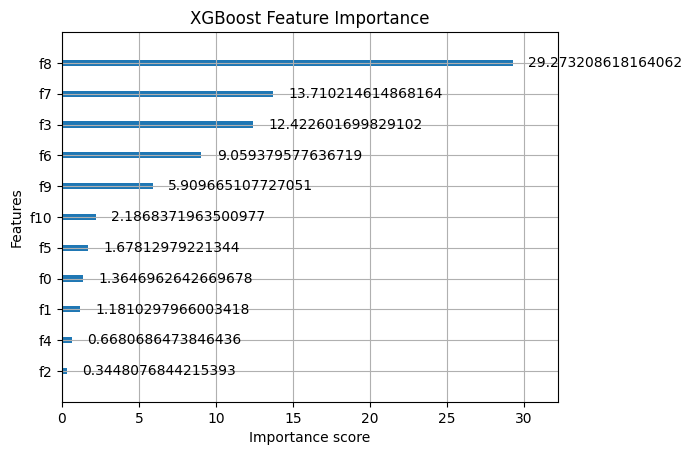

In [20]:
xgb.plot_importance(xgb_model, importance_type='gain')
plt.title('XGBoost Feature Importance')
plt.show()


## Validation

In [21]:
print("CV AUC:", cross_val_score(rf, X_scaled, y, cv=5, scoring='roc_auc').mean())

CV AUC: 0.9941273204297285


In [22]:
y_train_shuffled = np.random.permutation(y_train)
rf.fit(X_train, y_train_shuffled)
print("AUC with shuffled targets:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
# Should be near 0.5!


AUC with shuffled targets: 0.41054678563257835
